# Data Preprocessing

In [ ]:
pip install -U pymoo --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install ucimlrepo --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install fairlearn --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install fairlearn matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install EMP-PY --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import xgboost as xgb
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
warnings.filterwarnings("ignore")

## data import

In [ ]:
from ucimlrepo import fetch_ucirepo

# import German dataset (https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data)
polish_companies_bankruptcy = fetch_ucirepo(id=365)

# data (as pandas dataframes)
X = polish_companies_bankruptcy.data.features
y = polish_companies_bankruptcy.data.targets


# sample 50% of data (for performance)
# X = X.sample(frac=0.2) # use 20% of rows
# y = y.iloc[X.index]

print(X.shape)
print(y.shape)

# replace NAs with mean
X.fillna(X.mean(), inplace=True)

print(X.shape)

X.head()

(43405, 65)
(43405, 1)
(43405, 65)


,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16,A17,A18,A19,A20,A21,A22,A23,A24,A25,A26,A27,A28,A29,A30,A31,A32,A33,A34,A35,A36,A37,A38,A39,A40,A41,A42,A43,A44,A45,A46,A47,A48,A49,A50,A51,A52,A53,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63,A64
0,1,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,0.249760,0.65980,0.166600,0.249760,497.42,0.73378,2.6349,0.249760,0.149420,43.370,1.247900,0.21402,0.119980,0.477060,0.50494,0.60411,1.45820,1.7615,5.9443,0.11788,0.149420,94.14,3.8772,0.56393,0.21402,1.7410,593.270000,0.50591,0.128040,0.662950,0.051402,0.128040,114.42,71.050,1.00970,1.52250,49.394,0.185300,0.110850,2.0420,0.37854,0.25792,2.2437,2.2480,348690.0,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277
1,1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,0.261140,0.51680,0.158350,0.258340,677.96,0.53838,2.0005,0.258340,0.152000,87.981,1.429300,0.24806,0.123040,0.270012,0.39542,0.43992,88.44400,16.9460,3.6884,0.26969,0.152000,122.17,2.9876,2.98760,0.20616,1.6996,105.075944,0.49788,0.121300,0.086422,0.064371,0.145950,199.49,111.510,0.51045,1.12520,100.130,0.237270,0.139610,1.9447,0.49988,0.33472,17.8660,17.8660,2304.6,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870
2,1,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,0.312580,0.64184,0.244350,0.309060,794.16,0.45961,1.4369,0.309060,0.236100,73.133,1.428300,0.30260,0.189960,0.270012,0.28932,0.37282,86.01100,1.0627,4.3749,0.41929,0.238150,176.93,2.0630,1.42740,0.31565,1.3090,2.301900,0.51537,0.241140,0.322020,0.074020,0.231170,165.51,92.381,0.94807,1.01010,96.372,0.291810,0.222930,1.0758,0.48152,0.48474,1.2098,2.0504,6332.7,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078
3,1,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,0.092704,0.30163,0.094257,0.092704,917.01,0.39803,3.2537,0.092704,0.071428,79.788,1.506900,0.11550,0.062782,0.171930,0.57353,0.36152,0.94076,1.9618,4.6511,0.14343,0.071428,91.37,3.9948,0.37581,0.11550,1.3562,105.075944,0.57353,0.088995,0.401390,0.069622,0.088995,180.77,100.980,0.28720,1.56960,84.344,0.085874,0.066165,2.4928,0.30734,0.25033,2.4524,2.4524,20545.0,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497
4,1,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,0.187320,0.33147,0.121820,0.187320,1133.20,0.32211,1.6307,0.187320,0.115530,57.045,3.884997,0.19832,0.115530,0.187320,0.38677,0.32211,1.41380,1.1184,4.1424,0.27884,0.115530,147.04,2.4823,0.32340,0.19832,1.6278,11.247000,0.43489,0.122310,0.293040,0.096680,0.122310,141.62,84.574,0.73919,0.95787,65.936,0.188110,0.116010,1.2959,0.56511,0.40285,1.8839,2.1184,3186.6,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980


## PCA

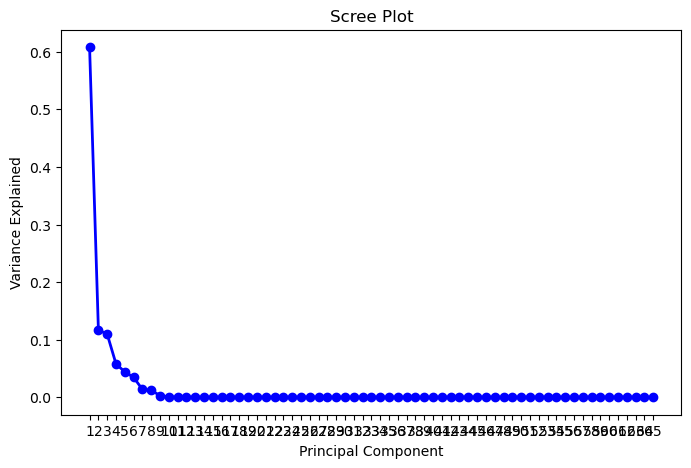

In [ ]:
from sklearn.decomposition import PCA

pca = PCA().fit(X) # n_components=pca_components

explained_variance = pca.explained_variance_ratio_

# Create the scree plot
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained_variance) + 1), explained_variance, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.xticks(np.arange(1, len(explained_variance) + 1))
plt.show()

In [ ]:
### PCA ###
pca_components = 8 # based on explained variance above

pca = PCA(n_components=pca_components)
X_reduced = pca.fit_transform(X) # also standardises

print(X_reduced.shape)
print(X.shape)

# convert to df
colnames = ["A" + str(i) for i in range(pca_components)]
X = pd.DataFrame(X_reduced, columns=colnames)

X

(43405, 8)
(43405, 65)


,A0,A1,A2,A3,A4,A5,A6,A7
0,-2001.227442,-1853.533375,-1180.854117,341003.082167,1696.254238,2482.521600,-913.725945,-234.409607
1,-1737.405356,-1080.843861,-1317.308081,-5362.474682,-387.626462,-504.151793,-1022.475041,-449.270615
2,-1756.853592,-1036.120046,-1197.620246,-1335.165611,-350.984204,-424.584539,-1022.597065,-446.009139
3,-1776.692426,-1149.981941,-1062.818152,12876.925829,-324.433528,-351.108006,-1099.644485,-437.935831
4,-1780.912627,-1062.058395,-860.958098,-4481.467156,-377.436257,-440.810472,-1108.915006,-446.630345
...,...,...,...,...,...,...,...,...
43400,-1910.671695,-1089.602985,4510.662055,-4072.816980,-585.925763,-431.291990,-1107.678799,-438.943713
43401,-1930.352150,-1148.454683,-2742.442430,-16910.008861,-313.083699,-496.184001,-9.878049,-348.957169
43402,-1698.863424,-909.663118,-5341.080842,-65916.259076,-450.532713,-912.562186,-37.848663,-479.203387
43403,-1859.235693,-1237.138325,-7340.431842,-6557.194031,-111.295885,-466.583770,-4.740033,-439.267934


## train-test split

In [ ]:
from sklearn.model_selection import train_test_split

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape, y_train.shape)

(30383, 8) (30383, 1)


# Optimization

## grid search

In [ ]:
# %%time
# import xgboost as xgb
# from xgboost import XGBClassifier
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import accuracy_score, make_scorer
# from EMP.metrics import empCreditScoring

# ### GRID SEARCH ###

# # Step 1 #
# clf = XGBClassifier().fit(X_train, y_train)
# y_pred_proba = clf.predict_proba(X_test)[:, 1]

# # Step 2: Define the XGBoost model
# model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# # Step 3: Define the parameter grid
# param_grid = {
#     'n_estimators': [50, 100, 200],  # Number of trees
#     'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage
#     'max_depth': [3, 4, 5],  # Maximum tree depth
#     'subsample': [0.8, 1.0],  # Subsample ratio of training instances
#     'colsample_bytree': [0.8, 1.0],  # Subsample ratio of columns
#     'gamma': [0, 1, 5],  # Minimum loss reduction
# }

# scores = y_pred_proba
# classes = y_test.values
# emp_score = empCreditScoring(scores, classes, rounding=3)[0]

# emp_scorer = make_scorer(emp_score, needs_proba=True, greater_is_better=True)

# # Step 4: Define GridSearchCV
# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     scoring='accuracy',
#     # scoring=emp_scorer,
#     cv=5,  # 5-fold cross-validation
#     verbose=1,
#     n_jobs=-1
# )

# # Step 5: Fit the model
# grid_search.fit(X_train, y_train)

# # Step 6: Evaluate the best model
# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test)
# accuracy = accuracy_score(y_test, y_pred)

# # XGB Best Parameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
# print(f"Best Parameters: {grid_search.best_params_}")
# print(f"Test Accuracy: {accuracy:.4f}")

In [ ]:
# %%time

# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV

# ### RF Grid Search ###
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# grid_search = GridSearchCV(estimator=RandomForestClassifier(),
#                            param_grid=param_grid,
#                            cv=5,  # Number of cross-validation folds
#                            scoring='accuracy',  # Metric to optimize
#                            verbose=2,  # Print progress
#                            n_jobs=-1)  # Use all available cores


# grid_search.fit(X_train, y_train)

# print("Best Parameters:", grid_search.best_params_) # [max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100]
# print("Best Score:", grid_search.best_score_)

# rf_params = grid_search.best_params_
# # rf_params_list = [max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100]

# rf_params

## EMP

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from EMP.metrics import empCreditScoring

### EMP func ###
def emp_func(no_of_features, direction="forward"):
  # FS
  fs = SequentialFeatureSelector(LogisticRegression(),
                                 n_features_to_select=no_of_features,
                                 direction=direction)
  fs.fit(X_train, y_train)
  X_train_new = fs.transform(X_train)
  X_test_new = fs.transform(X_test)

  # print("Features selected: ", fs.get_feature_names_out())

  # train classification model with selected features
  clf = XGBClassifier(colsample_bytree= 1.0,
                      gamma= 0,
                      learning_rate= 0.1,
                      max_depth= 5,
                      n_estimators= 50,
                      subsample= 0.8).fit(X_train_new, y_train) # params based on acc

  scores = clf.predict_proba(X_test_new)[:, 1] # y_pred_proba
  classes = y_test.values

  emp_score = empCreditScoring(scores, classes, rounding=3) # Will print and return output with k decimal points

  print("number of features: ", no_of_features, ", EMP: ", emp_score)

  return emp_score[0]

In [ ]:
emp_func(3)

number of features:  3 , EMP:  output(EMPC=0.002, EMPC_fraction=0.008)


0.002

In [ ]:
%%time

# create results dict
results_emp = {}

for i in range(1, len(X.columns)):
  results_emp[i] = emp_func(i)

# print(results_emp)

# converto to pd Series
df_res_emp = pd.Series(results_emp)

df_res_emp.head()

number of features:  1 , EMP:  output(EMPC=0.0, EMPC_fraction=0.0)
number of features:  2 , EMP:  output(EMPC=0.002, EMPC_fraction=0.008)
number of features:  3 , EMP:  output(EMPC=0.002, EMPC_fraction=0.008)
number of features:  4 , EMP:  output(EMPC=0.002, EMPC_fraction=0.009)
number of features:  5 , EMP:  output(EMPC=0.003, EMPC_fraction=0.009)
number of features:  6 , EMP:  output(EMPC=0.003, EMPC_fraction=0.009)
number of features:  7 , EMP:  output(EMPC=0.003, EMPC_fraction=0.01)
CPU times: total: 39min 32s
Wall time: 11min 40s


1    0.000
2    0.002
3    0.002
4    0.002
5    0.003
dtype: float64

## Fairness

In [ ]:
from fairlearn.metrics import MetricFrame
from fairlearn.metrics import selection_rate
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

### Fairness Function ###
# https://fairlearn.org/v0.10/quickstart.html

def fair_func(no_of_features): # !!! fix fairness calc

  # FS: SFS
  fs = SequentialFeatureSelector(LogisticRegression(), n_features_to_select=no_of_features)
  fs.fit(X_train, y_train)

  # create new X_train and X_test based on selected features
  X_train_new = fs.transform(X_train)
  X_test_new = fs.transform(X_test)
  # print("Features selected: ", fs.get_feature_names_out())

  # classification
  #clf = XGBClassifier(colsample_bytree= 1.0,
  #                    gamma= 0,
  #                    learning_rate= 0.1,
  #                max_depth= 5,
  #                    n_estimators= 50,
  #                    subsample= 0.8)

  clf = RandomForestClassifier() # as otherwise fairness score always same
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)

  mf = MetricFrame(metrics=accuracy_score, # [selection_rate, accuracy_score]
                  y_true=y_test,
                  y_pred=y_pred,
                  sensitive_features=X_test["A7"] # can be categorical
                  )

  fair_score = mf.overall.round(3)
  # fair_score_group = mf.by_group

  print("number of features: ", no_of_features, ", fairness: ", fair_score)

  return fair_score

fair_func(3)

number of features:  3 , fairness:  0.954


0.954

In [ ]:
%%time

# create results dict
results_fair = {}

for i in range(1, len(X.columns)):
  results_fair[i] = fair_func(i)

# print(results_emp)

# converto to pd Series
df_res_fair = pd.Series(results_fair)

df_res_fair

number of features:  1 , fairness:  0.954
number of features:  2 , fairness:  0.955
number of features:  3 , fairness:  0.954
number of features:  4 , fairness:  0.954
number of features:  5 , fairness:  0.954
number of features:  6 , fairness:  0.954
number of features:  7 , fairness:  0.954
CPU times: total: 36min 9s
Wall time: 13min 54s


1    0.954
2    0.955
3    0.954
4    0.954
5    0.954
6    0.954
7    0.954
dtype: float64

# 1-Obj

In [ ]:
# max value from results dict/list
emp_scores = df_res_emp.tolist()

max_emp = max(emp_scores) # emp_scores, df_res_emp, results_emp
max_emp_ind = emp_scores.index(max(emp_scores))+1
max_emp_perc = round(max_emp_ind/(len(emp_scores)+1), 3)*100

print("maximum EMP: ", max_emp, ", ", max_emp_ind, "/", len(emp_scores)+1,
      " features used(", max_emp_perc,"%)")

print("fairness w/ max.EMP feature count:", df_res_fair[max_emp_ind])
print("CPU time: ")

maximum EMP:  0.003 ,  5 / 8  features used( 62.5 %)
fairness w/ max.EMP feature count: 0.954
CPU time: 


In [ ]:
%%time
emp_func(max_emp_ind)

number of features:  5 , EMP:  output(EMPC=0.003, EMPC_fraction=0.009)
CPU times: total: 7min 17s
Wall time: 1min 55s


0.003

Text(0, 0.5, 'EMP')

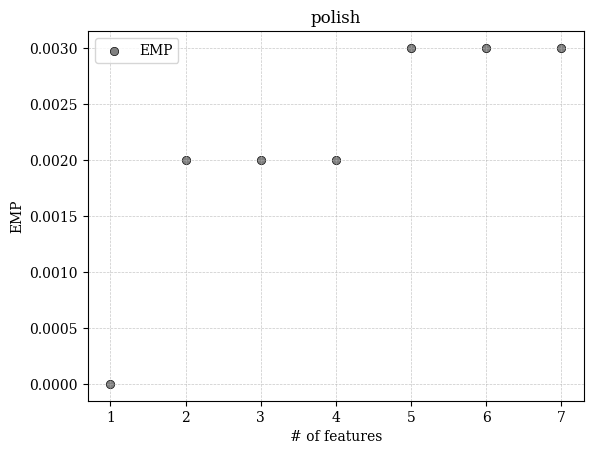

In [ ]:
# TODO: format maximum value (solution)
# TODO: add data labels for max
# TODO: add AUC and/or Acc on plot

# Scatterplot EMP - # Features
sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_emp, label="EMP", color = "grey", edgecolor="black")

# add second axis to plot
# ax2 = plt.twinx()
# sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_auc, label="AUC", color="orange", ax=ax2, alpha=0.5, s=20) # size=
# sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_acc, label="Acc", color="green", ax=ax2, alpha=0.2)

plt.grid(True, which="both", axis="both", linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend() #loc="upper left"
plt.title('polish')
plt.xlabel('# of features')
plt.ylabel('EMP')

# 2-Obj

In [ ]:
from pymoo.problems.functional import FunctionalProblem

# problem def & opti, plot
max_n_features = max(results_emp.keys())

def restrain_integer_sampling(n_features):
  if n_features > max_n_features:
    return max_n_features
  elif n_features < 1:
    return 1
  else:
    return n_features

def calculate_emp(n_features):
  return -1*results_emp[n_features]

def minimize_n_features(n_features):
  return n_features

def maximize_fairness(n_features):
  return -1*results_fair[n_features]

In [ ]:
# With IntegerRandomSampling
objs = [
    lambda x: calculate_emp(restrain_integer_sampling(abs(int(x[0])))),
    lambda x: minimize_n_features(restrain_integer_sampling(abs(int(x[0])))),
    # lambda x: maximize_fairness(restrain_integer_sampling(abs(int(x[0]))))
]

n_var = 1

problem = FunctionalProblem(
    n_var,
    objs,
    # constr_ieq=constr_ieq,
    xl=np.array([1]),
    xu=np.array([5]),
    vtype=[int, int]
)

N_features_to_try = [3]  # Integer Random Sampling

F = problem.evaluate(np.array(N_features_to_try).reshape(len(N_features_to_try), 1)) # convert from (1) to (1, 1)

print(f"F: {F}\n")

F: [[-2.e-03  3.e+00]]



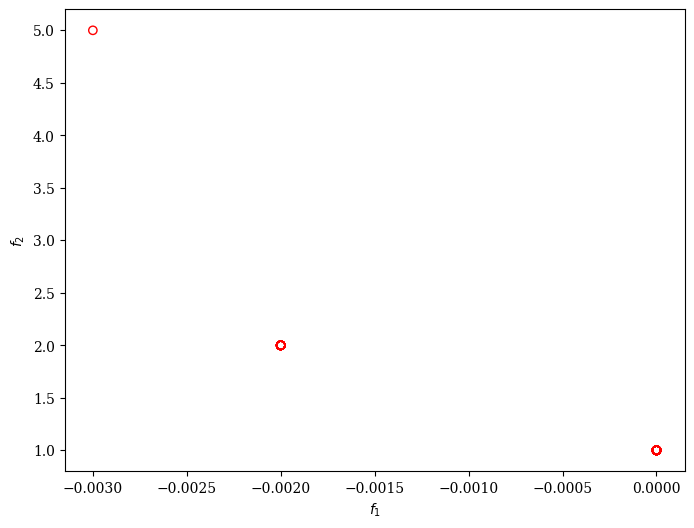

In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.operators.crossover.sbx import SimulatedBinaryCrossover
from pymoo.operators.mutation.pm import PolynomialMutation

algorithm = NSGA2(
    pop_size=100,
    sampling = IntegerRandomSampling(),
    crossover=SimulatedBinaryCrossover(eta=15, prob=0.9),
    mutation=PolynomialMutation(),
    eliminate_duplicates=True
  )

res = minimize(problem,
               algorithm,
               ('n_gen', 100),
               seed=1,
               verbose=False)
# Plot
plot = Scatter()

plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
# plt.title("2-Obj Opti")
# plt.gca().invert_xaxis()
# plt.grid(True)

plot.show() # TODO: remove top blank visual

In [ ]:
# calculate number of features for best solution
emp_list_2obj = [abs(i) for i, j in res.F]
fs_counts_2obj = [j for i, j in res.F]

max_emp_2obj = max(emp_list_2obj)
max_fs_counts_2obj = int(max(fs_counts_2obj))
# print("Number of features:", max_fs_counts)

# Output
print("2-Obj Opti Results: ", "", sep="\n")
print("max EMP:", max_emp_2obj)
print("Fairness score:", fair_func(max_fs_counts_2obj))
# print("CPU time: ", round(res.exec_time, 3))
print("CPU time: (see below)")

2-Obj Opti Results: 

max EMP: 0.003
number of features:  5 , fairness:  0.954
Fairness score: 0.954
CPU time: (see below)


In [ ]:
%%time
emp_func(max_fs_counts_2obj)

number of features:  5 , EMP:  output(EMPC=0.003, EMPC_fraction=0.009)
CPU times: total: 7min 26s
Wall time: 1min 50s


0.003

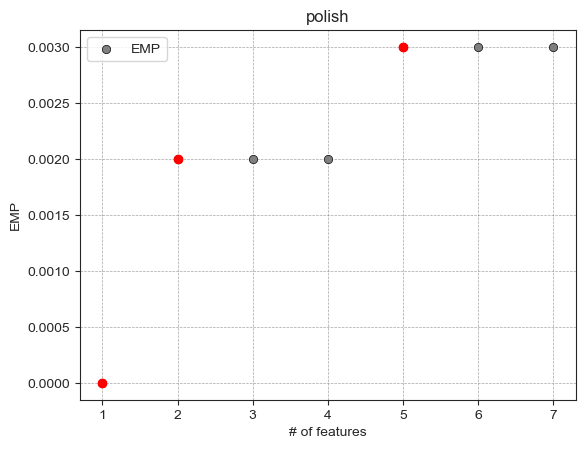

In [ ]:
### plot w/SO scatter ###

def plot_solution(X_train, df_res_emp, highlight_indices=None):
  """highilight solutions"""
  # Scatterplot EMP - # Features
  sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_emp, label="EMP", color="grey", edgecolor="black")

  plt.grid(True, which="both", axis="both", linestyle='--', linewidth=0.5, alpha=0.7, color="grey")
  plt.legend() #loc="upper left"
  plt.title('polish')
  plt.xlabel('# of features')
  plt.ylabel('EMP')

  if highlight_indices is not None:
    # Add a single point with a different color
    # plt.scatter(highlight_indices, X_train.iloc[highlight_indices], color='red', label='Special Point')
    plt.scatter(highlight_indices, df_res_emp[highlight_indices], color='red', label='Special Point')
    pass # TODO

plot_solution(X_train, df_res_emp, np.unique(res.F[:, 1]))
# plot_solution(X_train, df_res_emp)

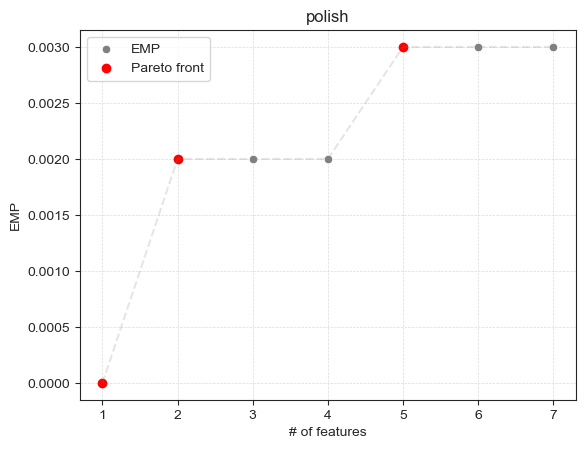

In [ ]:
### plot w/SO scatter ###

def plot_solution_2d(x, y, parameters={}, highlight_indices=None):
  """highilight solutions"""
  # Scatterplot EMP - # Features
  sns.scatterplot(x=x, y=y, label=parameters.get('label'), color='grey')
  plt.plot(x, y, linestyle='--', color='grey', alpha=0.2)  # Add connecting line


  plt.grid(True, which="both", axis="both", linestyle='--', linewidth=0.5, alpha=0.7)

  plt.title(parameters.get('title'))
  plt.xlabel(parameters.get('x_label'))
  plt.ylabel(parameters.get('y_label'))

  if highlight_indices is not None:
    # Add a single point with a different color
    # plt.scatter(highlight_indices, X_train.iloc[highlight_indices], color='red', label='Special Point')
    plt.scatter(highlight_indices, df_res_emp[highlight_indices], color='red', label='Pareto front')

  plt.legend() #loc="upper left"

parameters = {
    'label': "EMP",
    'title': 'polish',
    'x_label': '# of features',
    'y_label': 'EMP',
}
plot_solution_2d(list(range(1, len(X_train.columns))), df_res_emp, parameters, np.unique(res.F[:, 1]))
# plot_solution(X_train, df_res_emp)

# 3-Obj

In [ ]:
# With IntegerRandomSampling
objs = [
    lambda x: calculate_emp(restrain_integer_sampling(abs(int(x[0])))),
    lambda x: minimize_n_features(restrain_integer_sampling(abs(int(x[0])))),
    lambda x: maximize_fairness(restrain_integer_sampling(abs(int(x[0]))))
]

n_var = 1

problem = FunctionalProblem(
    n_var,
    objs,
    xl=np.array([1]),
    xu=np.array([5]),
    vtype=[int, int]
)

N_features_to_try = [3]  # Integer Random Sampling

F = problem.evaluate(np.array(N_features_to_try).reshape(len(N_features_to_try), 1)) # convert from (1) to (1, 1)

print(f"F: {F}\n")

F: [[-2.00e-03  3.00e+00 -9.54e-01]]



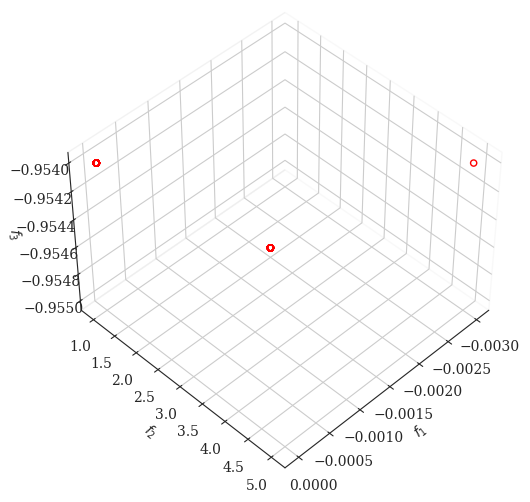

In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.operators.crossover.sbx import SimulatedBinaryCrossover
from pymoo.operators.mutation.pm import PolynomialMutation

algorithm = NSGA2(
    pop_size=100,
    sampling = IntegerRandomSampling(),
    crossover=SimulatedBinaryCrossover(eta=15, prob=0.9),
    mutation=PolynomialMutation(),
    eliminate_duplicates=True
  )

res = minimize(problem,
               algorithm,
               ('n_gen', 100),
               seed=1,
               verbose=False)
# Plot
plot = Scatter()

plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
# plt.title("3-Obj Opti")
# plt.gca().invert_xaxis()

plot.show()

In [ ]:
# calculate number of features for best solution
emp_list = [abs(i) for i, j, k in res.F]
fs_counts = [j for i, j, k in res.F]
fair_scores = [k for i, j, k in res.F]

max_emp = max(emp_list)
max_fs_counts = int(max(fs_counts))
# print("Number of features:", max_fs_counts)

### OUTPUT ###
print("3-Obj Opti Results: ", "", sep="\n")
print("max EMP:", max_emp)
# print("CPU time: ", round(res.exec_time, 3))
print("Fairness score:", fair_func(max_fs_counts))

3-Obj Opti Results: 

max EMP: 0.003
number of features:  5 , fairness:  0.955
Fairness score: 0.955


In [ ]:
%%time
emp_func(max_fs_counts)

number of features:  5 , EMP:  output(EMPC=0.003, EMPC_fraction=0.009)
CPU times: total: 6min 7s
Wall time: 37.7 s


0.003

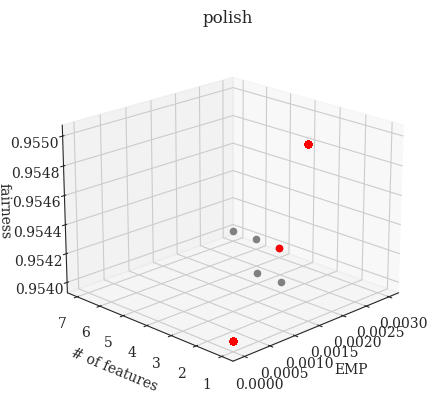

In [ ]:
def plot_solution_3d(x, y, z, point_labels, parameters={}, highlight_indices=None):
  # Create a figure and a 3D subplot
  fig = plt.figure()
  ax = fig.add_subplot(111, projection='3d')

  # Create the 3D scatter plot using Seaborn's color palette
  # darkgrid, whitegrid, dark, white, ticks
  sns.set_style("ticks") # Set Seaborn style
  # ax.scatter(x, y, z, c=z, cmap=sns.color_palette("viridis", as_cmap=True))  # Color points by z-value

  grey_idx = point_labels == "2-obj"
  red_idx = point_labels == "3-obj"
  ax.scatter(x[grey_idx], y[grey_idx], z[grey_idx], c="grey", depthshade=False)  # Color points by z-value
  ax.scatter(x[red_idx], y[red_idx], z[red_idx], c="red", depthshade=False)  # Color points by z-value
  ax.view_init(elev=20, azim=225) # Example angles

  # Set labels and title
  ax.set_xlabel(parameters.get("x_label"))
  ax.set_ylabel(parameters.get("y_label"))
  ax.set_zlabel(parameters.get("z_label"))
  ax.set_title(parameters.get("title"))

  plt.show()


# Convert results to 3D DataFrame -- 3-Obj
res_f_df = pd.DataFrame(res.F, columns=["f1", "f2", "f3"])
res_f_df = res_f_df.abs()
res_f_df["label"] = "3-obj"


# Convert the Series to 3D DataFrame - 2-Obj
df_res_emp_for_3d = pd.DataFrame(df_res_emp, columns=['f1'])  # Series to DataFrame
df_res_emp_for_3d["f2"] = range(1, len(df_res_emp)+1) # Add 'f2' column
df_res_emp_for_3d["f3"] = df_res_fair # Add 'f3' column
df_res_emp_for_3d["label"] = "2-obj"
df_res_emp_for_3d = df_res_emp_for_3d[["f1", "f2", "f3", "label"]]

merged_results = pd.concat([res_f_df, df_res_emp_for_3d], axis=0)

# res_f_df_1st_dim = res_f_df.iloc[:, 0]
# res_f_df_2nd_dim = res_f_df.iloc[:, 1]
# res_f_df_3rd_dim = res_f_df.iloc[:, 2]

df_1st_dim = merged_results.iloc[:, 0]
df_2nd_dim = merged_results.iloc[:, 1]
df_3rd_dim = merged_results.iloc[:, 2]
df_point_labels = merged_results.iloc[:, 3]

plot_solution_3d(
    x=df_1st_dim,
    y=df_2nd_dim,
    z=df_3rd_dim,
    point_labels=df_point_labels,
    parameters={'label': "EMP", 'title': 'polish', 'x_label': 'EMP', 'y_label': '# of features', 'z_label': 'fairness'}
)

# all feats

In [ ]:
print("EMP with all features:", results_emp[max(results_emp.keys())])
print("# features used: ", len(X_train.columns))
print("Fairness with all feats:", results_fair[max(results_fair.keys())])
print("CPU times: see below")

EMP with all features: 0.003
# features used:  8
Fairness with all feats: 0.954
CPU times: see below


In [ ]:
%%time
emp_func(len(X.columns)-1)

number of features:  7 , EMP:  output(EMPC=0.003, EMPC_fraction=0.01)
CPU times: total: 8min 41s
Wall time: 2min 11s


0.003

In [ ]:
%%timeit
emp_func(len(X.columns)-1)

number of features:  7 , EMP:  output(EMPC=0.003, EMPC_fraction=0.01)
number of features:  7 , EMP:  output(EMPC=0.003, EMPC_fraction=0.01)
number of features:  7 , EMP:  output(EMPC=0.003, EMPC_fraction=0.01)
number of features:  7 , EMP:  output(EMPC=0.003, EMPC_fraction=0.01)
number of features:  7 , EMP:  output(EMPC=0.003, EMPC_fraction=0.01)
number of features:  7 , EMP:  output(EMPC=0.003, EMPC_fraction=0.01)
number of features:  7 , EMP:  output(EMPC=0.003, EMPC_fraction=0.01)
number of features:  7 , EMP:  output(EMPC=0.003, EMPC_fraction=0.01)
2min 33s ± 37.9 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%time emp_func(len(X.columns)-1)

number of features:  7 , EMP:  output(EMPC=0.003, EMPC_fraction=0.01)
CPU times: total: 8min 3s
Wall time: 2min 2s


0.003

# all results

In [ ]:
### 1-Obj ###
print("--- 1-Obj Results----")
print("")
print("EMP: ", max_emp, ", ", max_emp_ind, "/", len(emp_scores),
      "(", max_emp_perc,"%) features used")
print("fairness:", df_res_fair[max_emp_ind])
print("CPU time: ")

--- 1-Obj Results----

EMP:  0.003 ,  5 / 7 ( 62.5 %) features used
fairness: 0.954
CPU time: 


In [ ]:
%%time
emp_func(max_fs_counts_2obj)

In [ ]:
### 3-Obj ###
print("--- 3-Obj Results----")
print("")
print("EMP:", max_emp)
print("Fairness:", fair_func(max_fs_counts))
print("CPU times: see below")

In [ ]:
%%time
emp_func(max_fs_counts)

In [ ]:
### Full Model ###
print("--- Full Model----")
print("")
print("EMP with all features:", results_emp[max(results_emp.keys())])
print("# features used: ", len(X_train.columns))
print("Fairness with all feats:", results_fair[max(results_fair.keys())])
print("CPU times: see below")

In [ ]:
%%time
emp_func(len(X.columns)-1)